<a href="https://colab.research.google.com/github/TenofJiwon/DerivativeSecurities/blob/main/Option_Pricing_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from scipy import stats
import numpy as np

def option_price(S, K, ttm, r, sigma):
  d1=(np.log(S/K)+(r+sigma**2*0.5)*ttm)/(sigma*np.sqrt(ttm))
  d2=(np.log(S/K)+(r-sigma**2*0.5)*ttm)/(sigma*np.sqrt(ttm))
  #val=(S*stats.norm.cdf(d1,0.0,1.0))-K*np.exp(-r*ttm)*stats.norm.cdf(d2,0.0,1.0) #콜옵션
  val=-(S*stats.norm.cdf(-d1,0.0,1.0))+K*np.exp(-r*ttm)*stats.norm.cdf(-d2,0.0,1.0) #풋옵션
  return val

S_0=42; Strike_price=40; rf=0.05; vol=0.2; T=6/12;

print(option_price(S_0, Strike_price, T, rf, vol))

1.0928995494642386


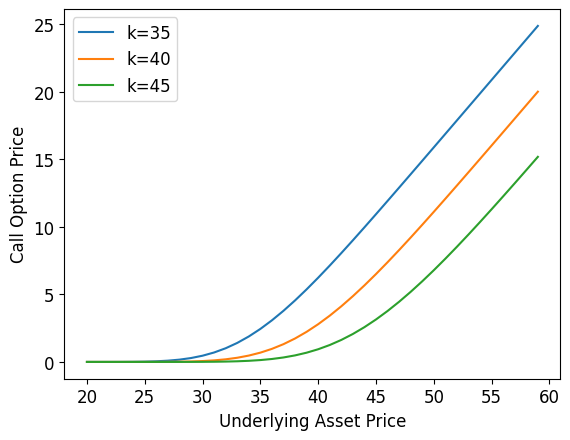

In [ ]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def call_price(S,K,ttm,r,sigma):
   d1=(np.log(S/K)+(r+sigma**2*0.5)*ttm)/(sigma*np.sqrt(ttm))
   d2=(np.log(S/K)+(r-sigma**2*0.5)*ttm)/(sigma*np.sqrt(ttm))
   val=(S*stats.norm.cdf(d1,0.0,1.0))-K*np.exp(-r*ttm)*stats.norm.cdf(d2,0.0,1.0)
   return val

ttm=np.busday_count('2025-06-13','2025-12-11')/252
r=0.05
sigma=0.20

call_space=dict()
K=np.arange(30,50,1)
S=np.arange(20,60,1)

for k in K:
  single_space=dict()
  for s in S:
    single_space[s]=call_price(s,k,ttm,r,sigma)
  call_space[k]=pd.Series(single_space)
df_call_space=pd.DataFrame(call_space)

#plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['font.size']=12

plt.plot(df_call_space[35], label='k=35')
plt.plot(df_call_space[40], label='k=40')
plt.plot(df_call_space[45], label='k=45')
plt.xlabel('Underlying Asset Price')
plt.ylabel('Call Option Price')
plt.legend(loc='best')
plt.show()

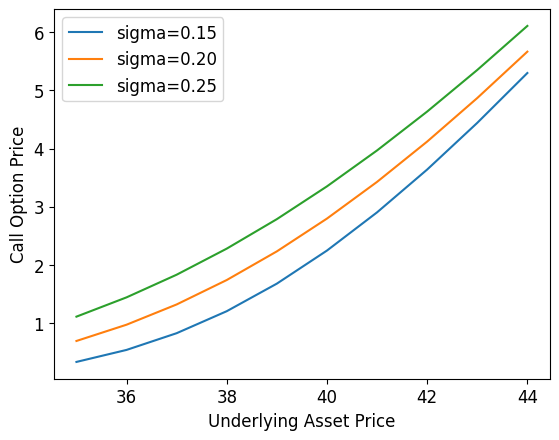

In [ ]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def call_price(S,K,ttm,r,sigma):
   d1=(np.log(S/K)+(r+sigma**2*0.5)*ttm)/(sigma*np.sqrt(ttm))
   d2=(np.log(S/K)+(r-sigma**2*0.5)*ttm)/(sigma*np.sqrt(ttm))
   val=(S*stats.norm.cdf(d1,0.0,1.0))-K*np.exp(-r*ttm)*stats.norm.cdf(d2,0.0,1.0)
   return val

ttm=np.busday_count('2025-06-13','2025-12-11')/252
r=0.05
K=40

call_space=dict()
sigma=np.round(np.arange(0.10,0.30,0.01), 2)
S=np.arange(35,45,1)

for sig in sigma:
  single_space=dict()
  for s in S:
    single_space[s]=call_price(s,K,ttm,r,sig)
  call_space[sig]=pd.Series(single_space)
df_call_space=pd.DataFrame(call_space)

plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['font.size']=12

plt.plot(df_call_space[0.15], label='sigma=0.15')
plt.plot(df_call_space[0.20], label='sigma=0.20')
plt.plot(df_call_space[0.25], label='sigma=0.25')
plt.xlabel('Underlying Asset Price')
plt.ylabel('Call Option Price')
plt.legend(loc='best')
plt.show()

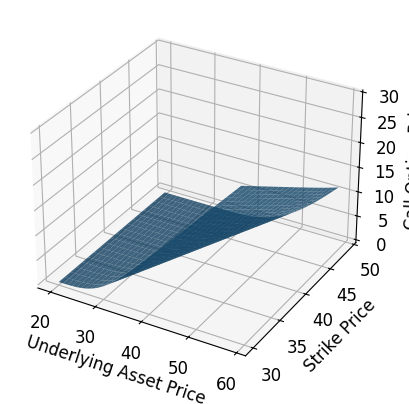

In [ ]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def call_price(S,K,ttm,r,sigma):
   d1=(np.log(S/K)+(r+sigma**2*0.5)*ttm)/(sigma*np.sqrt(ttm))
   d2=(np.log(S/K)+(r-sigma**2*0.5)*ttm)/(sigma*np.sqrt(ttm))
   val=(S*stats.norm.cdf(d1,0.0,1.0))-K*np.exp(-r*ttm)*stats.norm.cdf(d2,0.0,1.0)
   return val

ttm=np.busday_count('2025-06-13','2025-12-11')/252
r=0.05
sigma=0.20

K=np.arange(30,50,1)
S=np.arange(20,60,1)

K, S=np.meshgrid(K,S)
Z=call_price(S,K,ttm,r,sigma)

plt.rcParams['font.family']='Times New Roman'
plt.rcParams['font.size']=12

fig=plt.figure()
ax=fig.add_subplot(projection='3d')
ax.plot_surface(S,K,Z,linewidth=1,antialiased=True,alpha=0.8)
ax.set_xlabel('Underlying Asset Price')
ax.set_ylabel('Strike Price')
ax.set_zlabel('Call Option Price')
plt.show()

In [ ]:
import numpy as np
N=126; S=np.zeros([N,1]); S[0]=42
vol=0.2; r=0.05; T=6/12; dt=T/N; K=40

iter_num=10000
payoff=np.zeros([iter_num,1])

for k in range(0,iter_num):
  z=np.random.normal(0,1,N)
  for i in range(N-1):
    S[i+1,0]=S[i,0]*np.exp((r-0.5*vol**2)*dt+vol*z[i]*np.sqrt(dt)) #여기까지 지난시간 시뮬레이션
  payoff[k,0]=np.maximum(K-S[-1],0)

pv_payoff=np.exp(-r*T)*np.sum(payoff)/iter_num
print('Option price: %.3f' %(pv_payoff))

/tmp/ipython-input-1321527530.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  payoff[k,0]=np.maximum(K-S[-1],0)


Option price: 1.098
